In [1]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn hmmlearn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Human Activity Recognition using Hidden Markov Models


## 1. Imports and Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.fft import fft
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = Path('data/raw')
UNSEEN_DIR = Path('data/unseen')
ACTIVITIES = ['still', 'standing', 'walking', 'jumping']
TARGET_HZ  = 50

# Two scales — 1s catches standing detail, 2s catches walking rhythm
WINDOW_SEC  = 2.0
WINDOW_LEN  = int(TARGET_HZ * WINDOW_SEC)   # 100 samples
STEP_LEN    = WINDOW_LEN // 2               # 50% overlap
SHORT_LEN   = int(TARGET_HZ * 1.0)          # 50 samples — 1s sub-window

print('Libraries loaded OK')
print(f'Long window:  {WINDOW_LEN} samples = {WINDOW_SEC}s')
print(f'Short window: {SHORT_LEN} samples = 1.0s (used inside each long window)')

Libraries loaded OK
Long window:  100 samples = 2.0s
Short window: 50 samples = 1.0s (used inside each long window)


## 2. Load and Resample Raw Data

In [3]:
SENSOR_COLS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

def load_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    cols = [c for c in SENSOR_COLS if c in df.columns]
    return df[cols].dropna().values.astype(float)

def resample_signal(data, original_hz, target_hz=TARGET_HZ):
    if original_hz == target_hz:
        return data
    n_target = int(len(data) * target_hz / original_hz)
    return resample(data, n_target, axis=0)

def estimate_hz(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    if 'time' not in df.columns:
        return TARGET_HZ
    t = pd.to_numeric(df['time'], errors='coerce').dropna().values
    if len(t) < 2:
        return TARGET_HZ
    diffs = np.diff(t)
    median_diff = np.median(diffs)
    if median_diff > 1e6:
        hz = 1e9 / median_diff
    elif median_diff > 1e3:
        hz = 1e6 / median_diff
    elif median_diff > 1:
        hz = 1e3 / median_diff
    else:
        hz = 1.0 / median_diff
    return round(hz)

raw_data = {}
sampling_rates = {}

for act in ACTIVITIES:
    raw_data[act] = []
    files = sorted((DATA_DIR / act).glob('*.csv'))
    for f in files:
        hz = estimate_hz(f)
        sampling_rates[f.name] = hz
        data = load_csv(f)
        data = resample_signal(data, hz)
        raw_data[act].append(data)
    print(f'{act}: {len(files)} files loaded')

print('\nSampling rates detected:')
for fname, hz in sampling_rates.items():
    print(f'  {fname}: {hz} Hz')

still: 10 files loaded
standing: 10 files loaded
walking: 10 files loaded
jumping: 10 files loaded

Sampling rates detected:
  still_01.csv: 100 Hz
  still_02.csv: 100 Hz
  still_03.csv: 100 Hz
  still_04.csv: 100 Hz
  still_05.csv: 100 Hz
  still_06.csv: 50 Hz
  still_07.csv: 50 Hz
  still_08.csv: 50 Hz
  still_09.csv: 50 Hz
  still_10.csv: 50 Hz
  standing_01.csv: 100 Hz
  standing_02.csv: 100 Hz
  standing_03.csv: 100 Hz
  standing_04.csv: 100 Hz
  standing_05.csv: 100 Hz
  standing_06.csv: 100 Hz
  standing_07.csv: 100 Hz
  standing_08.csv: 100 Hz
  standing_09.csv: 100 Hz
  standing_10.csv: 100 Hz
  walking_01.csv: 100 Hz
  walking_02.csv: 100 Hz
  walking_03.csv: 100 Hz
  walking_04.csv: 100 Hz
  walking_05.csv: 100 Hz
  walking_06.csv: 100 Hz
  walking_07.csv: 100 Hz
  walking_08.csv: 100 Hz
  walking_09.csv: 100 Hz
  walking_10.csv: 100 Hz
  jumping_01.csv: 100 Hz
  jumping_02.csv: 100 Hz
  jumping_03.csv: 100 Hz
  jumping_04.csv: 100 Hz
  jumping_05.csv: 100 Hz
  jumping_06.cs

## 3. Feature Extraction

In [4]:
def extract_features_single_scale(window, win_len):
    """Features from one window at one scale."""
    feats = []
    n_cols = window.shape[1]

    # Time-domain
    feats.extend(np.mean(window, axis=0))
    feats.extend(np.var(window, axis=0))
    feats.extend(np.std(window, axis=0))
    feats.extend(np.max(window, axis=0) - np.min(window, axis=0))
    feats.extend(np.percentile(window, 75, axis=0) - np.percentile(window, 25, axis=0))

    # Magnitude features (accel axes 0-2)
    sma = np.mean(np.sum(np.abs(window[:, :3]), axis=1))
    vm  = np.mean(np.sqrt(np.sum(window[:, :3]**2, axis=1)))
    feats.append(sma)
    feats.append(vm)

    # Zero-crossing rate per axis — key for separating still vs standing
    for col_i in range(n_cols):
        zcr = np.mean(np.diff(np.sign(window[:, col_i])) != 0)
        feats.append(zcr)

    # Gyroscope RMS — still on table ≈ 0, standing (hand tremor) > 0
    if n_cols >= 6:
        gyro_rms = np.sqrt(np.mean(window[:, 3:]**2))
        feats.append(gyro_rms)

    # Axis correlations
    for i, j in [(0,1),(0,2),(1,2)]:
        corr = np.corrcoef(window[:,i], window[:,j])[0,1]
        feats.append(0.0 if np.isnan(corr) else corr)

    # Frequency-domain
    for col_i in range(n_cols):
        spectrum = np.abs(fft(window[:, col_i]))[:win_len//2]
        freqs = np.fft.fftfreq(win_len, d=1/TARGET_HZ)[:win_len//2]
        dominant_freq    = freqs[np.argmax(spectrum[1:]) + 1]
        spectral_energy  = np.sum(spectrum**2)
        spectral_entropy = -np.sum((spectrum/spectrum.sum()) * np.log(spectrum/spectrum.sum() + 1e-10))
        feats.extend([dominant_freq, spectral_energy, spectral_entropy])

    return np.array(feats)

def extract_features(window):
    """Multi-scale: concatenate features from full 2s window + first 1s sub-window."""
    feats_long  = extract_features_single_scale(window, WINDOW_LEN)
    feats_short = extract_features_single_scale(window[:SHORT_LEN], SHORT_LEN)
    return np.concatenate([feats_long, feats_short])

def sliding_windows(data, window_len=WINDOW_LEN, step=STEP_LEN):
    return [data[s:s+window_len] for s in range(0, len(data)-window_len+1, step)]

X_all = []
y_all = []
label_map = {act: i for i, act in enumerate(ACTIVITIES)}

for act in ACTIVITIES:
    for recording in raw_data[act]:
        for win in sliding_windows(recording):
            X_all.append(extract_features(win))
            y_all.append(label_map[act])

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f'Feature matrix shape: {X_all.shape}')
print(f'Features per window: {X_all.shape[1]} (multi-scale: {X_all.shape[1]//2} long + {X_all.shape[1]//2} short)')
print(f'\nSamples per activity:')
for act, idx in label_map.items():
    print(f'  {act}: {np.sum(y_all == idx)} windows')

Feature matrix shape: (608, 120)
Features per window: 120 (multi-scale: 60 long + 60 short)

Samples per activity:
  still: 151 windows
  standing: 153 windows
  walking: 154 windows
  jumping: 150 windows


## 4. Normalize Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print('Features normalized (mean=0, std=1)')
print(f'Shape: {X_scaled.shape}')

Features normalized (mean=0, std=1)
Shape: (608, 120)


## 5. Build and Train the HMM

In [6]:
N_ITER = 200
N_RESTARTS = 5

# still only supports 2 components — its signal is too flat for more sub-states
ACTIVITY_COMPONENTS = {
    'still':    2,
    'standing': 4,
    'walking':  4,
    'jumping':  4,
}

models = {}

for act in ACTIVITIES:
    idx = label_map[act]
    X_act = X_scaled[y_all == idx]
    n_comp = ACTIVITY_COMPONENTS[act]

    best_model = None
    best_score = -np.inf

    for seed in range(N_RESTARTS):
        try:
            model = GaussianHMM(
                n_components=n_comp,
                covariance_type='diag',
                n_iter=N_ITER,
                tol=1e-4,
                min_covar=1e-3,
                random_state=seed
            )
            model.fit(X_act)
            s = model.score(X_act)
            if np.isfinite(s) and s > best_score:
                best_score = s
                best_model = model
        except Exception:
            continue

    if best_model is None:
        raise RuntimeError(f'All restarts failed for {act}')

    models[act] = best_model
    print(f'Trained HMM for [{act}] (n={n_comp}) — log-likelihood: {best_score:.2f}')

print('\nAll models trained.')

Trained HMM for [still] (n=2) — log-likelihood: 36024.26
Trained HMM for [standing] (n=4) — log-likelihood: 23767.31
Trained HMM for [walking] (n=4) — log-likelihood: -2473.25
Trained HMM for [jumping] (n=4) — log-likelihood: -13953.44

All models trained.


## 6. Predict with Viterbi

In [7]:
def predict_activity(feature_vector):
    scores = {act: models[act].score(feature_vector.reshape(1, -1)) for act in ACTIVITIES}
    return max(scores, key=scores.get)

def predict_sequence(X_seq):
    return [label_map[predict_activity(x)] for x in X_seq]

y_pred_train = np.array(predict_sequence(X_scaled))
train_acc = np.mean(y_pred_train == y_all)
print(f'Training accuracy: {train_acc:.2%}')
print()
print(classification_report(y_all, y_pred_train, target_names=ACTIVITIES))

Training accuracy: 83.06%

              precision    recall  f1-score   support

       still       0.85      0.97      0.91       151
    standing       0.73      0.82      0.78       153
     walking       0.98      0.58      0.73       154
     jumping       0.83      0.95      0.88       150

    accuracy                           0.83       608
   macro avg       0.85      0.83      0.82       608
weighted avg       0.85      0.83      0.82       608



## 7. Visualize Transition Matrices

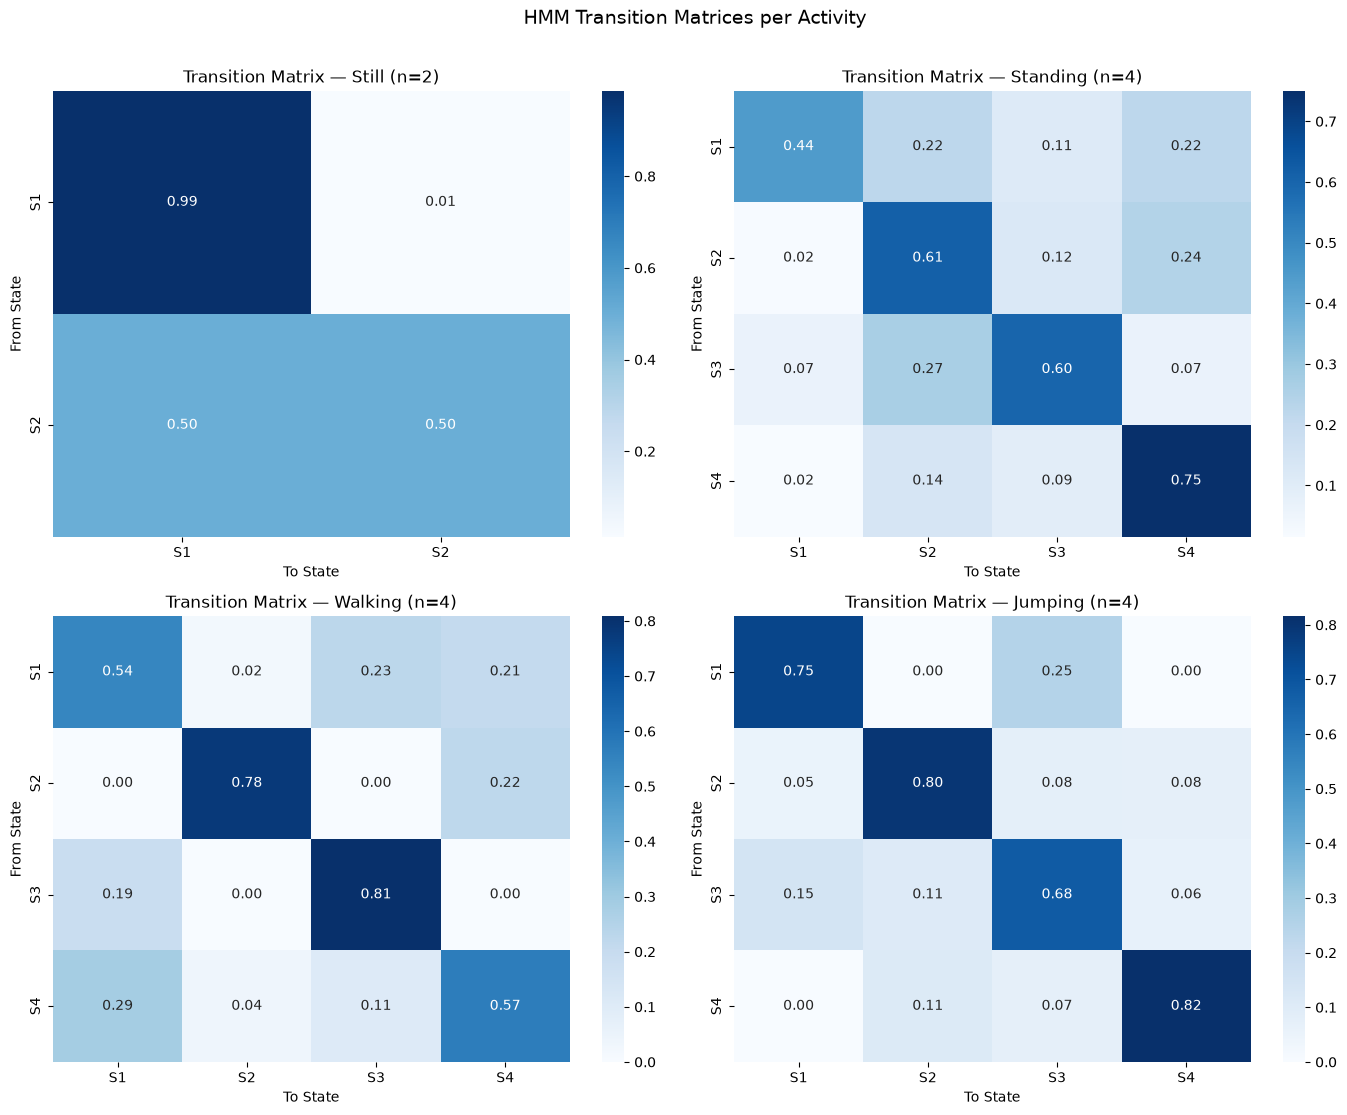

Saved transition_matrices.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, act in enumerate(ACTIVITIES):
    tm = models[act].transmat_
    n = tm.shape[0]
    sns.heatmap(
        tm, ax=axes[i], annot=True, fmt='.2f', cmap='Blues',
        xticklabels=[f'S{j+1}' for j in range(n)],
        yticklabels=[f'S{j+1}' for j in range(n)]
    )
    axes[i].set_title(f'Transition Matrix — {act.capitalize()} (n={n})')
    axes[i].set_xlabel('To State')
    axes[i].set_ylabel('From State')

plt.suptitle('HMM Transition Matrices per Activity', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved transition_matrices.png')

## 7b. Emission Probability Visualization

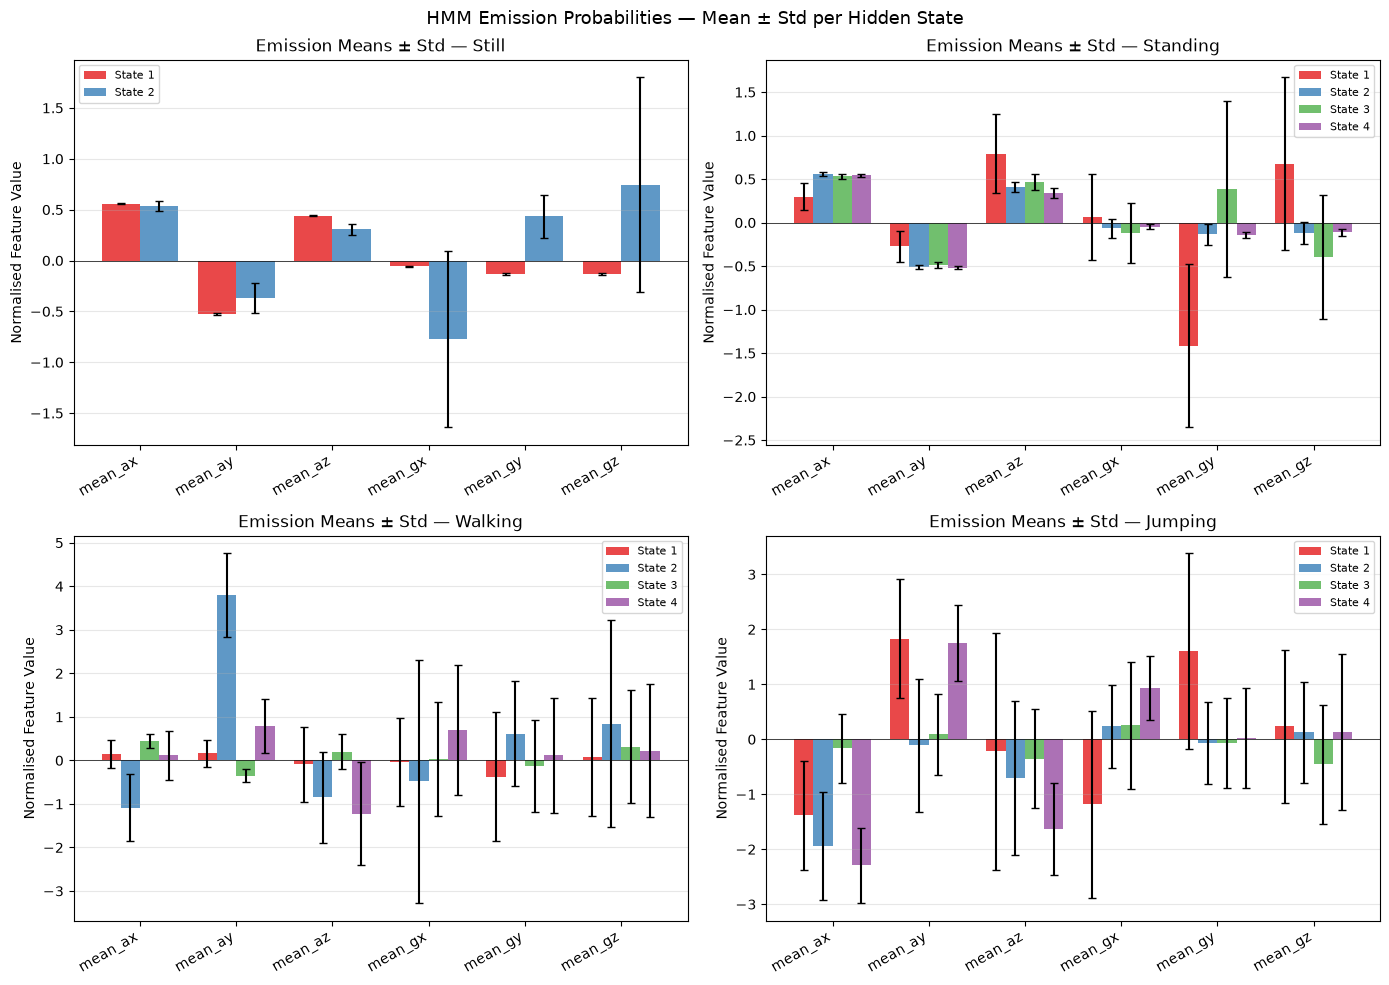

Saved emission_probabilities.png


In [10]:
# Emission probabilities: visualize the mean feature values per hidden state for each activity
# We show the first 6 features (mean of ax,ay,az,gx,gy,gz) as they are most interpretable

FEATURE_LABELS = ['mean_ax','mean_ay','mean_az','mean_gx','mean_gy','mean_gz']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors_states = ['#e41a1c','#377eb8','#4daf4a','#984ea3']

for i, act in enumerate(ACTIVITIES):
    model = models[act]
    n = model.n_components
    means = model.means_[:, :6]

    covars = model.covars_
    if covars.ndim == 3:
        vars_ = np.array([np.diag(covars[s])[:6] for s in range(n)])
    else:
        vars_ = covars[:, :6]
    stds = np.sqrt(np.clip(vars_, 0, None))

    x = np.arange(len(FEATURE_LABELS))
    width = 0.8 / n

    for s in range(n):
        offset = (s - n/2 + 0.5) * width
        axes[i].bar(x + offset, means[s], width,
                    yerr=stds[s], capsize=3,
                    label=f'State {s+1}', color=colors_states[s], alpha=0.8)

    axes[i].set_title(f'Emission Means ± Std — {act.capitalize()}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(FEATURE_LABELS, rotation=30, ha='right')
    axes[i].set_ylabel('Normalised Feature Value')
    axes[i].legend(fontsize=8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('HMM Emission Probabilities — Mean ± Std per Hidden State', fontsize=13)
plt.tight_layout()
plt.savefig('emission_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved emission_probabilities.png')

## 8. Plot Decoded Activity Sequences

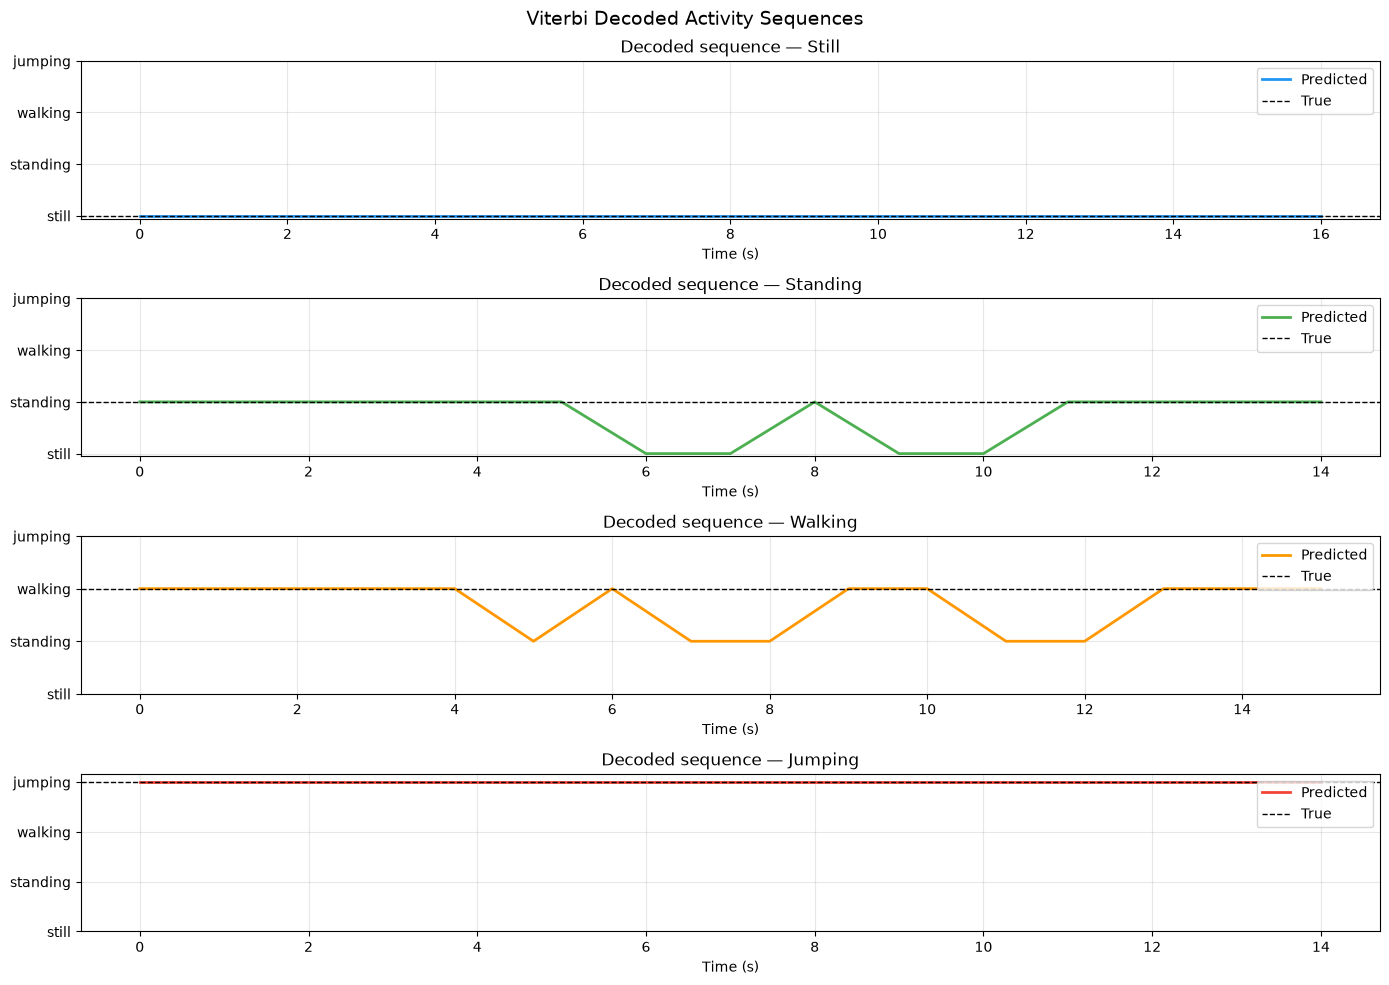

Saved decoded_sequences.png


In [11]:
fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 10), sharex=False)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, act in enumerate(ACTIVITIES):
    recording = raw_data[act][0]
    windows = sliding_windows(recording)
    if not windows:
        continue
    X_rec = np.array([extract_features(w) for w in windows])
    X_rec_scaled = scaler.transform(X_rec)
    preds = predict_sequence(X_rec_scaled)
    true_label = label_map[act]

    time_axis = np.arange(len(preds)) * (STEP_LEN / TARGET_HZ)
    axes[i].plot(time_axis, preds, color=colors[i], linewidth=2, label='Predicted')
    axes[i].axhline(true_label, color='black', linestyle='--', linewidth=1, label='True')
    axes[i].set_yticks(range(len(ACTIVITIES)))
    axes[i].set_yticklabels(ACTIVITIES)
    axes[i].set_title(f'Decoded sequence — {act.capitalize()}')
    axes[i].set_xlabel('Time (s)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Viterbi Decoded Activity Sequences', fontsize=14)
plt.tight_layout()
plt.savefig('decoded_sequences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved decoded_sequences.png')

## 9. Confusion Matrix (Training Set)

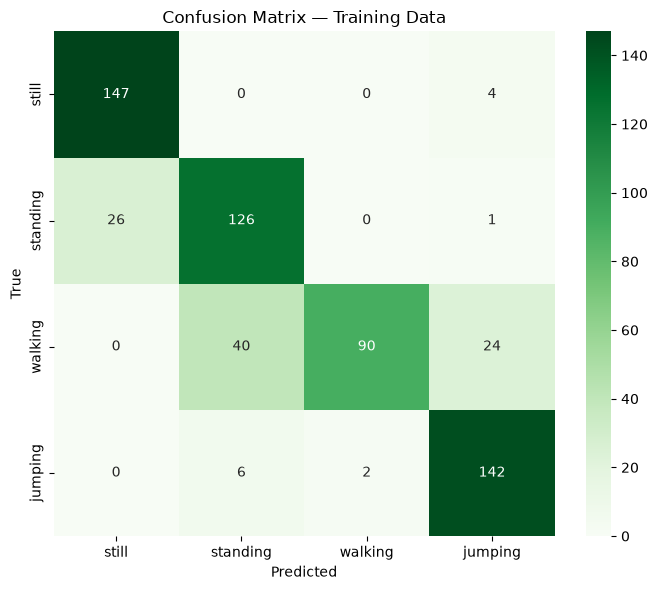

In [12]:
cm = confusion_matrix(y_all, y_pred_train)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=ACTIVITIES, yticklabels=ACTIVITIES
)
plt.title('Confusion Matrix — Training Data')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluate on Unseen Data

Unseen [still]: 15 windows loaded
Unseen [standing]: 15 windows loaded
Unseen [walking]: 15 windows loaded
Unseen [jumping]: 15 windows loaded

Unseen accuracy: 88.33%

              precision    recall  f1-score   support

       still       1.00      1.00      1.00        15
    standing       0.83      1.00      0.91        15
     walking       0.91      0.67      0.77        15
     jumping       0.81      0.87      0.84        15

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



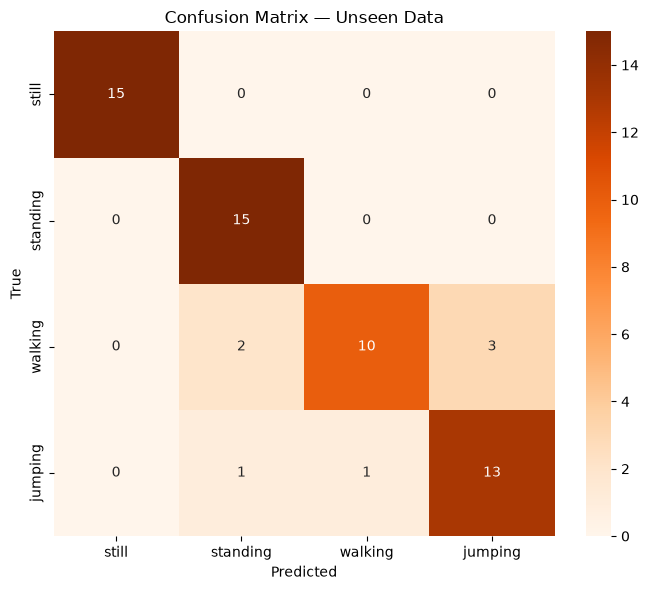

In [13]:
X_unseen = []
y_unseen = []

unseen_files = {
    'still':    UNSEEN_DIR / 'unseen_still.csv',
    'standing': UNSEEN_DIR / 'unseen_standing.csv',
    'walking':  UNSEEN_DIR / 'unseen_walking.csv',
    'jumping':  UNSEEN_DIR / 'unseen_jumping.csv',
}

for act, fpath in unseen_files.items():
    if not fpath.exists():
        print(f'Missing: {fpath} — skipping')
        continue
    hz = estimate_hz(fpath)
    data = load_csv(fpath)
    data = resample_signal(data, hz)
    wins = sliding_windows(data)
    for win in wins:
        X_unseen.append(extract_features(win))
        y_unseen.append(label_map[act])
    print(f'Unseen [{act}]: {len(wins)} windows loaded')

if X_unseen:
    X_unseen = np.array(X_unseen)
    y_unseen = np.array(y_unseen)
    X_unseen_scaled = scaler.transform(X_unseen)

    y_pred_unseen = np.array(predict_sequence(X_unseen_scaled))
    unseen_acc = np.mean(y_pred_unseen == y_unseen)
    print(f'\nUnseen accuracy: {unseen_acc:.2%}')
    print()
    print(classification_report(y_unseen, y_pred_unseen, target_names=ACTIVITIES))

    cm_unseen = confusion_matrix(y_unseen, y_pred_unseen)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm_unseen, annot=True, fmt='d', cmap='Oranges',
        xticklabels=ACTIVITIES, yticklabels=ACTIVITIES
    )
    plt.title('Confusion Matrix — Unseen Data')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig('confusion_matrix_unseen.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No unseen data found.')

## 11. Per-Class Metrics Table (Sensitivity / Specificity)

In [14]:
def per_class_metrics(y_true, y_pred, activities):
    rows = []
    for act in activities:
        idx = label_map[act]
        tp = np.sum((y_true == idx) & (y_pred == idx))
        fn = np.sum((y_true == idx) & (y_pred != idx))
        fp = np.sum((y_true != idx) & (y_pred == idx))
        tn = np.sum((y_true != idx) & (y_pred != idx))
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        n = np.sum(y_true == idx)
        rows.append({'Activity': act, 'Samples': n,
                     'Sensitivity': f'{sensitivity:.2%}',
                     'Specificity': f'{specificity:.2%}'})
    overall = np.mean(y_true == y_pred)
    rows.append({'Activity': 'OVERALL', 'Samples': len(y_true),
                 'Sensitivity': f'{overall:.2%}', 'Specificity': '—'})
    return pd.DataFrame(rows)

print('=== Training Data Metrics ===')
display(per_class_metrics(y_all, y_pred_train, ACTIVITIES))

if 'y_pred_unseen' in dir() and len(y_unseen) > 0:
    print('\n=== Unseen Data Metrics ===')
    display(per_class_metrics(y_unseen, y_pred_unseen, ACTIVITIES))

=== Training Data Metrics ===


,Activity,Samples,Sensitivity,Specificity
0,still,151,97.35%,94.31%
1,standing,153,82.35%,89.89%
2,walking,154,58.44%,99.56%
3,jumping,150,94.67%,93.67%
4,OVERALL,608,83.06%,—



=== Unseen Data Metrics ===


,Activity,Samples,Sensitivity,Specificity
0,still,15,100.00%,100.00%
1,standing,15,100.00%,93.33%
2,walking,15,66.67%,97.78%
3,jumping,15,86.67%,93.33%
4,OVERALL,60,88.33%,—


## 12. Raw Signal Visualization

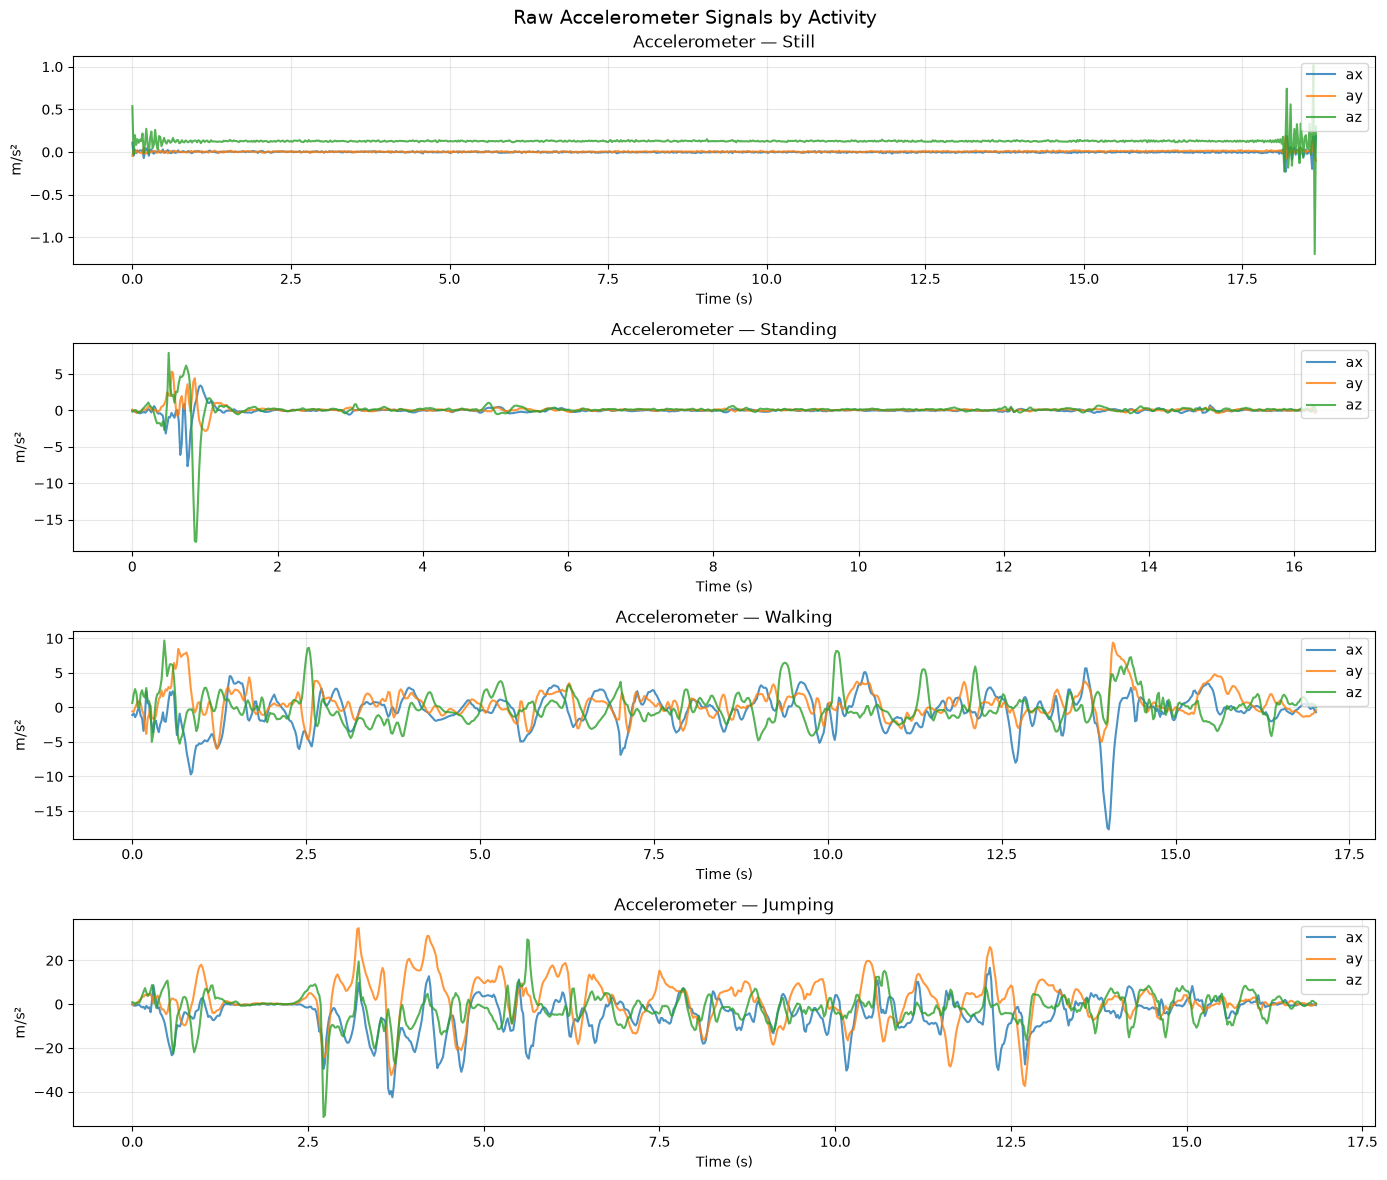

Saved raw_signals.png


In [15]:
fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(14, 12))

for i, act in enumerate(ACTIVITIES):
    data = raw_data[act][0]
    t = np.arange(len(data)) / TARGET_HZ
    axes[i].plot(t, data[:, 0], label='ax', alpha=0.8)
    axes[i].plot(t, data[:, 1], label='ay', alpha=0.8)
    axes[i].plot(t, data[:, 2], label='az', alpha=0.8)
    axes[i].set_title(f'Accelerometer — {act.capitalize()}')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('m/s²')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Raw Accelerometer Signals by Activity', fontsize=14)
plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved raw_signals.png')